# 05 — Intent classification under distribution shift

Notebook 01 shows every supervised model scoring 0.99+ macro-F1 on a random split. That
is a property of the corpus, not of the models: Bitext is template-generated, so a random
split puts near-identical phrasings on both sides and the ranking collapses into noise.

This notebook re-runs the comparison on a split that actually separates the models. Bitext
tags every utterance with linguistic *flags*:

| flag | meaning |
|---|---|
| `B` basic syntax, `L` semantic variation, `I` interrogative | "clean" phrasings |
| `Q` colloquial, `Z` noise (typos, missing punctuation), `W` offensive, `P` politeness | "hard" phrasings |

**The shifted split trains only on clean utterances and tests only on noisy/colloquial
ones** — the call-centre reality, where the model is trained on tidy text and then meets
ASR output full of disfluencies. Scores here are the ones worth quoting for deployment.

In [1]:
import sys, json, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common
from common import (
    Result, ResultStore, set_seed, device, env_info, timer, classification_metrics,
    plot_confusion, plot_benchmark, save_sklearn, ARTIFACTS, SEED,
)
import text_data as td

set_seed()
DEV = device()
store = ResultStore("intent_robustness_shift")
print(json.dumps(env_info(), indent=2))

{
  "python": "3.13.12",
  "platform": "Windows-11-10.0.26200-SP0",
  "torch": "2.13.0+cu132",
  "cuda_available": true,
  "gpu": "NVIDIA GeForce RTX 4050 Laptop GPU",
  "vram_gb": 6.0
}


## 1. Build the shifted split

In [2]:
HARD_FLAGS = set("QZWP")     # colloquial / noisy / offensive / over-polite
df = td.dedupe(td.load_bitext())
df["is_hard"] = df["flags"].apply(lambda f: bool(set(f) & HARD_FLAGS))

clean = df[~df.is_hard].reset_index(drop=True)
hard = df[df.is_hard].reset_index(drop=True)
print(f"clean utterances: {len(clean)}   hard utterances: {len(hard)}")

# Keep only intents present on both sides, otherwise the comparison is not well posed.
shared = sorted(set(clean["intent"]) & set(hard["intent"]))
clean = clean[clean.intent.isin(shared)].reset_index(drop=True)
hard = hard[hard.intent.isin(shared)].reset_index(drop=True)
LABELS = shared
print(f"intents kept: {len(LABELS)}")

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(clean, test_size=0.12, stratify=clean["intent"],
                                    random_state=SEED)
test_df = hard
y_train, y_val, y_test = train_df["intent"].values, val_df["intent"].values, test_df["intent"].values
print(f"train(clean)={len(train_df)}  val(clean)={len(val_df)}  test(HARD)={len(test_df)}")

# For reference, the same models are also scored on a held-out *clean* test set, so the
# gap between the two columns is the cost of the shift.
clean_train, clean_test = train_test_split(train_df, test_size=0.15,
                                           stratify=train_df["intent"], random_state=SEED)
print(f"in-distribution control: train={len(clean_train)}  test={len(clean_test)}")

clean utterances: 11969   hard utterances: 12056
intents kept: 27


train(clean)=10532  val(clean)=1437  test(HARD)=12056
in-distribution control: train=8952  test=1580


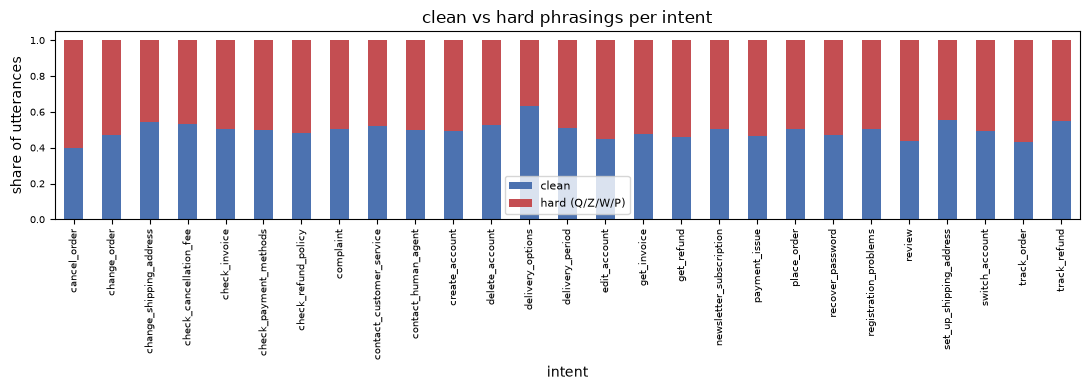

--- example hard utterances ---
   where can i switch to  the <ent> account
   need assistance seeing ur available payment methods
   I nmeed assistance calling customer support
   i want help speaking to a person
   wanna know about cancel the subscription to ur newsletter
   I'm trying to see in what cases can i ask for my money back
   i have to sede the cancellation charge
   how can i set the secondary shipping address up


In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
pd.crosstab(df["intent"], df["is_hard"], normalize="index").plot.bar(stacked=True, ax=ax,
                                                                    color=["#4C72B0", "#C44E52"])
ax.set_ylabel("share of utterances"); ax.set_title("clean vs hard phrasings per intent")
ax.legend(["clean", "hard (Q/Z/W/P)"], fontsize=8); ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

print("--- example hard utterances ---")
for t in test_df.sample(8, random_state=SEED)["text"]:
    print("  ", t)

## 2. Same model families, shifted evaluation

In [4]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

def word_tfidf():
    return TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True,
                           strip_accents="unicode")

def char_tfidf():
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, sublinear_tf=True)

PIPES = {
    "tfidf_word+logreg": Pipeline([("vec", word_tfidf()),
                                   ("clf", LogisticRegression(max_iter=2000, C=8.0, n_jobs=-1))]),
    "tfidf_word+char+linsvc": Pipeline([
        ("vec", FeatureUnion([("w", word_tfidf()), ("c", char_tfidf())])),
        ("clf", LinearSVC(C=1.0))]),
}

CONTROL = {}   # model -> in-distribution macro-F1, for the gap column

for name, pipe in PIPES.items():
    print(f"\n=== {name} ===")
    with timer("fit") as t:
        pipe.fit(train_df["text"], y_train)
    m = classification_metrics(y_test, pipe.predict(test_df["text"]))
    ctl = Pipeline(pipe.steps).fit(clean_train["text"], clean_train["intent"])
    CONTROL[name] = classification_metrics(clean_test["intent"],
                                           ctl.predict(clean_test["text"]))["macro_f1"]
    m["in_distribution_macro_f1"] = CONTROL[name]
    m["shift_drop"] = CONTROL[name] - m["macro_f1"]
    save_sklearn(pipe, f"shift_{name.replace('+', '_')}")
    store.add(Result("intent_robustness_shift", name, "traditional", m,
                     train_seconds=t.seconds, notes="trained on clean flags, tested on Q/Z/W/P"))


=== tfidf_word+logreg ===


[fit] 0.62s


  -> stored tfidf_word+logreg: accuracy=0.9772, balanced_acc=0.9740, macro_f1=0.9749, weighted_f1=0.9773, macro_precision=0.9772, macro_recall=0.9740, in_distribution_macro_f1=0.9942, shift_drop=0.0193

=== tfidf_word+char+linsvc ===


[fit] 2.33s


  -> stored tfidf_word+char+linsvc: accuracy=0.9949, balanced_acc=0.9940, macro_f1=0.9943, weighted_f1=0.9949, macro_precision=0.9947, macro_recall=0.9940, in_distribution_macro_f1=0.9966, shift_drop=0.0023


### Embedding and semantic-matching models

In [5]:
from sentence_transformers import SentenceTransformer

MINILM = "sentence-transformers/all-MiniLM-L6-v2"
encoder = SentenceTransformer(MINILM, device=DEV)

def embed(texts):
    return encoder.encode(list(texts), batch_size=256, convert_to_numpy=True,
                          normalize_embeddings=True, show_progress_bar=False)

E_train, E_test = embed(train_df["text"]), embed(test_df["text"])
E_ctl_tr, E_ctl_te = embed(clean_train["text"]), embed(clean_test["text"])

head = LogisticRegression(max_iter=3000, C=10.0, n_jobs=-1)
with timer("minilm+logreg") as t:
    head.fit(E_train, y_train)
m = classification_metrics(y_test, head.predict(E_test))
ctl = LogisticRegression(max_iter=3000, C=10.0, n_jobs=-1).fit(E_ctl_tr, clean_train["intent"])
m["in_distribution_macro_f1"] = classification_metrics(
    clean_test["intent"], ctl.predict(E_ctl_te))["macro_f1"]
m["shift_drop"] = m["in_distribution_macro_f1"] - m["macro_f1"]
save_sklearn(head, "shift_minilm_logreg")
store.add(Result("intent_robustness_shift", "minilm+logreg", "embedding", m,
                 train_seconds=t.seconds, notes="frozen encoder, clean-trained head"))

# Zero-shot uses no training text at all, so it cannot suffer a train/test shift — its
# score is the same on both sides by construction, which is the point.
P = embed(list(td.intent_prompts(LABELS).values()))
zs = np.array(LABELS)[(E_test @ P.T).argmax(1)]
m = classification_metrics(y_test, zs)
m["in_distribution_macro_f1"] = classification_metrics(
    clean_test["intent"], np.array(LABELS)[(E_ctl_te @ P.T).argmax(1)])["macro_f1"]
m["shift_drop"] = m["in_distribution_macro_f1"] - m["macro_f1"]
store.add(Result("intent_robustness_shift", "minilm_zeroshot_label_match", "embedding", m,
                 train_seconds=0.0, notes="no training text; immune to this shift by construction"))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[minilm+logreg] 1.06s


  -> stored minilm+logreg: accuracy=0.9794, balanced_acc=0.9774, macro_f1=0.9779, weighted_f1=0.9795, macro_precision=0.9788, macro_recall=0.9774, in_distribution_macro_f1=0.9960, shift_drop=0.0181


  -> stored minilm_zeroshot_label_match: accuracy=0.7264, balanced_acc=0.7186, macro_f1=0.7137, weighted_f1=0.7217, macro_precision=0.7298, macro_recall=0.7186, in_distribution_macro_f1=0.7489, shift_drop=0.0352


Result(task='intent_robustness_shift', model='minilm_zeroshot_label_match', family='embedding', metrics={'accuracy': 0.7264432647644327, 'balanced_acc': 0.7185971630191464, 'macro_f1': 0.7136783576233283, 'weighted_f1': 0.7216812436205178, 'macro_precision': 0.7297618585379533, 'macro_recall': 0.7185971630191464, 'in_distribution_macro_f1': 0.7488718499202472, 'shift_drop': 0.03519349229691893}, params={}, train_seconds=0.0, infer_ms_per_item=None, model_size_mb=None, n_params=None, notes='no training text; immune to this shift by construction')

### Fine-tuned DistilBERT, retrained on the clean half only

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

lab2id = {l: i for i, l in enumerate(LABELS)}

class TxtDS(Dataset):
    def __init__(self, texts, labels, tok, maxlen=48):
        self.enc = tok(list(texts), truncation=True, padding="max_length",
                       max_length=maxlen, return_tensors="pt")
        self.y = torch.tensor([lab2id[v] for v in labels])
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.y[i]
        return item


def finetune_eval(model_name, tag, train_texts, train_labels, eval_sets, epochs=3, lr=3e-5, bs=64):
    set_seed()
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(LABELS)).to(DEV)
    tr = DataLoader(TxtDS(train_texts, train_labels, tok), batch_size=bs, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=epochs * len(tr),
                                                pct_start=0.1)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEV == "cuda"))
    with timer(f"{tag} fine-tune") as t:
        for ep in range(epochs):
            model.train(); tot = 0.0
            for b in tr:
                b = {k: v.to(DEV) for k, v in b.items()}
                opt.zero_grad()
                with torch.amp.autocast("cuda", enabled=(DEV == "cuda")):
                    out = model(**b)
                scaler.scale(out.loss).backward(); scaler.step(opt); scaler.update(); sched.step()
                tot += out.loss.item() * len(b["labels"])
            print(f"  epoch {ep+1} loss={tot/len(tr.dataset):.4f}")

    preds = {}
    model.eval()
    for key, (texts, labels) in eval_sets.items():
        dl = DataLoader(TxtDS(texts, labels, tok), batch_size=128)
        out = []
        with torch.no_grad():
            for b in dl:
                b = {k: v.to(DEV) for k, v in b.items() if k != "labels"}
                out.append(model(**b).logits.argmax(1).cpu().numpy())
        preds[key] = np.array(LABELS)[np.concatenate(out)]
    return model, tok, preds, t.seconds


model, tok, preds, secs = finetune_eval(
    "distilbert-base-uncased", "distilbert_shift",
    train_df["text"], y_train,
    {"hard": (test_df["text"], y_test), "clean": (clean_test["text"], clean_test["intent"])},
)
m = classification_metrics(y_test, preds["hard"])
m["in_distribution_macro_f1"] = classification_metrics(clean_test["intent"],
                                                       preds["clean"])["macro_f1"]
m["shift_drop"] = m["in_distribution_macro_f1"] - m["macro_f1"]
out_dir = ARTIFACTS / "shift_distilbert_finetuned"
model.save_pretrained(out_dir); tok.save_pretrained(out_dir)
store.add(Result("intent_robustness_shift", "distilbert_finetuned", "deep", m,
                 train_seconds=secs, notes="trained on clean flags only"))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1 loss=1.6818


  epoch 2 loss=0.1319


  epoch 3 loss=0.0676
[distilbert_shift fine-tune] 44.53s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> stored distilbert_finetuned: accuracy=0.9631, balanced_acc=0.9582, macro_f1=0.9582, weighted_f1=0.9634, macro_precision=0.9597, macro_recall=0.9582, in_distribution_macro_f1=0.9986, shift_drop=0.0405


Result(task='intent_robustness_shift', model='distilbert_finetuned', family='deep', metrics={'accuracy': 0.9630889183808892, 'balanced_acc': 0.9582153953237557, 'macro_f1': 0.9581509180591854, 'weighted_f1': 0.9634071437759318, 'macro_precision': 0.9596984541997791, 'macro_recall': 0.9582153953237557, 'in_distribution_macro_f1': 0.9986153169241918, 'shift_drop': 0.04046439886500641}, params={}, train_seconds=44.53269150000051, infer_ms_per_item=None, model_size_mb=None, n_params=None, notes='trained on clean flags only')

## 3. How much does the shift cost each family?

                      model      family  accuracy  macro_f1  in_distribution_macro_f1  shift_drop
     tfidf_word+char+linsvc traditional    0.9949    0.9943                    0.9966      0.0023
              minilm+logreg   embedding    0.9794    0.9779                    0.9960      0.0181
          tfidf_word+logreg traditional    0.9772    0.9749                    0.9942      0.0193
       distilbert_finetuned        deep    0.9631    0.9582                    0.9986      0.0405
minilm_zeroshot_label_match   embedding    0.7264    0.7137                    0.7489      0.0352


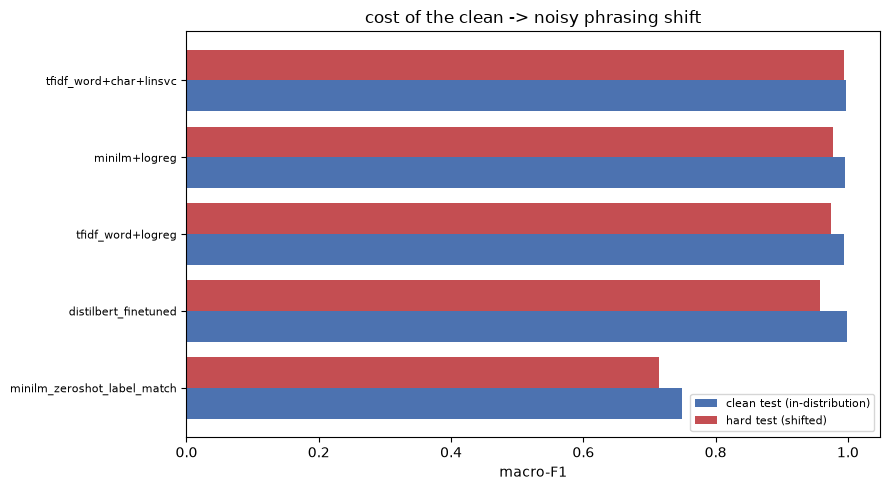

In [7]:
bench = store.frame(sort_by="macro_f1")
cols = ["model", "family", "accuracy", "macro_f1", "in_distribution_macro_f1", "shift_drop"]
print(bench[cols].round(4).to_string(index=False))
bench.to_csv(common.RESULTS / "summary_intent_shift.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
d = bench.sort_values("macro_f1")
y = np.arange(len(d))
ax.barh(y - 0.2, d["in_distribution_macro_f1"], height=0.4, label="clean test (in-distribution)",
        color="#4C72B0")
ax.barh(y + 0.2, d["macro_f1"], height=0.4, label="hard test (shifted)", color="#C44E52")
ax.set_yticks(y); ax.set_yticklabels(d["model"], fontsize=8)
ax.set_xlabel("macro-F1"); ax.set_title("cost of the clean -> noisy phrasing shift")
ax.legend(fontsize=8); plt.tight_layout()
fig.savefig(common.RESULTS / "intent_shift_gap.png", dpi=150)
plt.show()

In [8]:
best = bench.iloc[0]["model"]
err = pd.DataFrame({"text": test_df["text"], "true": y_test,
                    "pred": preds["hard"] if best == "distilbert_finetuned" else None})
if err["pred"].notna().all():
    err = err[err.true != err.pred]
    print(f"{len(err)} errors on the hard split ({100*len(err)/len(test_df):.2f}%)")
    print(err.groupby(["true", "pred"]).size().sort_values(ascending=False).head(10))
    err.head(30).to_csv(common.RESULTS / "intent_shift_error_samples.csv", index=False)

## 4. Notes for the report

* Quote **both** columns: the random-split scores from notebook 01 show the ceiling, the
  shifted scores here show what survives contact with messy input. The `shift_drop`
  column is the number that distinguishes the models.
* Character n-grams matter under noise: they degrade far less than word-only features
  because typos leave most character n-grams intact.
* The zero-shot row is the control — it never saw training text, so its two columns
  differ only by how hard each test set is, not by any train/test shift.
* This split still understates the real problem: ASR output adds disfluencies, wrong word
  boundaries and translation artefacts that no Bitext flag simulates. The honest next step
  is to label a few hundred utterances from the call transcripts of notebook 03 and score
  these same models against those.

In [9]:
print(f"results -> {store.path}")

results -> D:\DSEP22\model testing\results\intent_robustness_shift.json
